predizione su lordo per genere (usando year genere e film_usciti) 
biglietti_venduti
[E' possibile fare una predizione sul guadagno annuo del genere?]

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

df = pd.read_pickle('Film.pickle')
# Inizializzazione dello stile
plt.style.use('seaborn-v0_8-whitegrid')

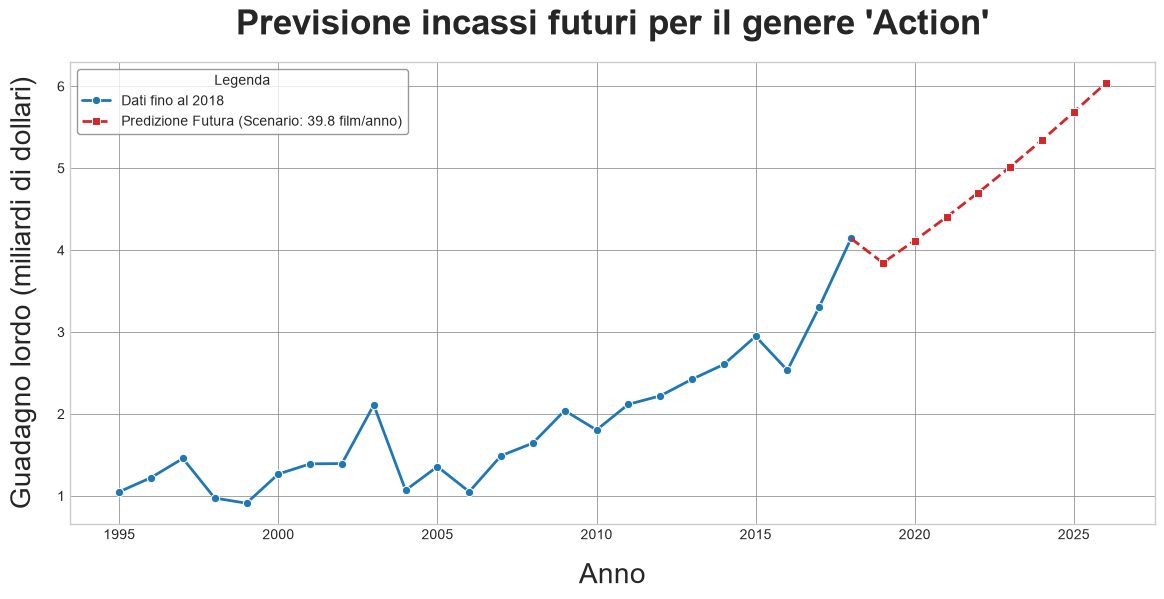

In [2]:
df_action = df[df['genere'] == 'Action'].sort_values('year')

# variabili indipendenti in x e var target in y
indip = df_action[['year', 'film_usciti']]
target = df_action['lordo']

poly_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False))
])
indip_poly = poly_pipeline.fit_transform(indip)

# creo i modello e gli dò i dati in pasto
modello = LinearRegression()
modello.fit(indip_poly, target)

#previsione anni da 2019 a 2027
anni_futuri = np.arange(2019, 2027)
media = df_action['film_usciti'].mean()
film_ipotizzati = [media] * len(anni_futuri) # uso la media degli anni precedenti
df_futuro = pd.DataFrame({
    'year': anni_futuri,
    'film_usciti': film_ipotizzati
})

df_futuro_poly = poly_pipeline.transform(df_futuro[['year', 'film_usciti']])

# faccio la previsione
df_futuro['lordo_predetto'] = modello.predict(df_futuro_poly)

#grafico
plt.figure(figsize=(14, 6))
ax = sns.lineplot(data=df_action, x='year', y='lordo', 
             marker='o', color='#1f77b4', linewidth=2, label='Dati fino al 2018', zorder=3)

# unisco i dati vecchi alle previsioni
df_con_previsioni = df_action.iloc[-1]
anni = [df_con_previsioni['year']] + list(df_futuro['year'])
lordo = [df_con_previsioni['lordo']] + list(df_futuro['lordo_predetto'])

# aggiungo la predizione
sns.lineplot(x=anni, y=lordo, 
             linestyle='--', marker='s', markevery=range(1, len(anni)), color='#d62728', linewidth=2, 
             label=f'Predizione Futura (Scenario: {media:.1f} film/anno)', zorder=3)

# assi
# assi
plt.title('Previsione incassi futuri per il genere \'Action\'', fontsize=25, fontweight='bold', pad=20)
plt.xlabel('Anno', fontsize=20, fontweight='normal', labelpad=15)
plt.ylabel('Guadagno lordo (miliardi di dollari)', fontsize=20, fontweight='normal', labelpad=15)
plt.grid(True, which='major', color='gray', linestyle='-', linewidth=0.5, zorder=1)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x * 1e-9:.0f}"))

# Lehenda
plt.legend(title='Legenda', frameon=True, facecolor='white', edgecolor='gray')

# Salvataggio
plt.savefig("figures/4_1.png", bbox_inches='tight')
plt.savefig("figures/4_1.svg", bbox_inches='tight')